# 06 - Comparison Dashboard

Aggregates the `results/*.csv` files produced by notebooks 01-05 into one
comparison table and a couple of plots. **Run notebooks 01-05 first** (in
any order) so their CSVs exist.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
import glob
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
print("Found result files:", [os.path.basename(f) for f in csv_files])

dfs = [pd.read_csv(f) for f in csv_files]
if not dfs:
    raise FileNotFoundError(
        "No results/*.csv found -- run notebooks 01_baselines through "
        "05_skill_memory_demo first, each writes its own CSV here."
    )
all_results = pd.concat(dfs, ignore_index=True)
all_results.head()


Found result files: ['01_baselines.csv', '02_regularization.csv', '03_replay.csv', '04_architectural.csv', '05_skill_memory.csv']


,strategy,category,after_experience,stream_acc,stream_forgetting,n_skills_stored,decisions
0,Naive,baseline,0,0.218,0.000000,NaN,NaN
1,Naive,baseline,1,0.302,0.477064,NaN,NaN
2,Naive,baseline,2,0.396,0.500000,NaN,NaN
3,Naive,baseline,3,0.254,0.894231,NaN,NaN
4,Naive,baseline,4,0.306,0.857406,NaN,NaN


## Final accuracy & forgetting per strategy (after the last experience)

In [2]:
final_per_strategy = (
    all_results.sort_values("after_experience")
    .groupby("strategy", as_index=False)
    .last()[["strategy", "category", "stream_acc", "stream_forgetting"]]
    .sort_values("stream_acc", ascending=False)
)
final_per_strategy


,strategy,category,stream_acc,stream_forgetting
2,Cumulative,baseline,1.000,0.000000
3,ER-ACE,replay,1.000,0.000000
11,SkillMemory,skill-memory (demo),1.000,0.000000
7,JointTraining,baseline,1.000,0.000000
5,GDumb,replay,1.000,0.000000
10,Replay,replay,0.996,0.004808
6,GEM,replay,0.994,0.006881
1,CWR*,architectural,0.992,0.000000
0,A-GEM,replay,0.350,0.798384
12,SynapticIntelligence,regularization,0.344,0.805851


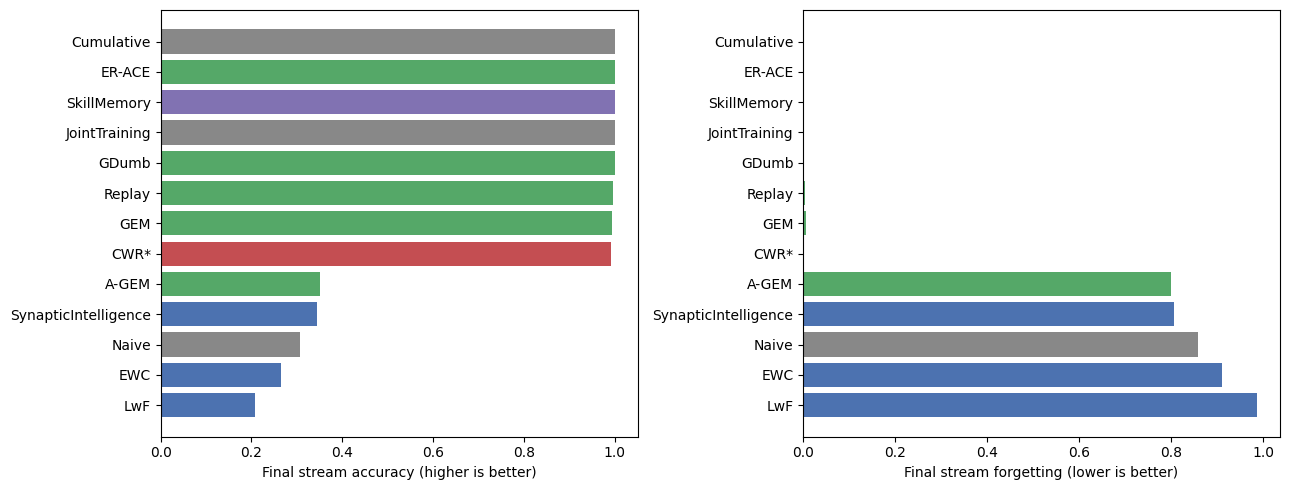

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = final_per_strategy["strategy"]
colors = final_per_strategy["category"].map({
    "baseline": "#888888",
    "regularization": "#4C72B0",
    "replay": "#55A868",
    "architectural": "#C44E52",
    "skill-memory (demo)": "#8172B2",
}).fillna("#333333")

axes[0].barh(final_per_strategy["strategy"], final_per_strategy["stream_acc"], color=colors)
axes[0].set_xlabel("Final stream accuracy (higher is better)")
axes[0].invert_yaxis()

axes[1].barh(final_per_strategy["strategy"], final_per_strategy["stream_forgetting"], color=colors)
axes[1].set_xlabel("Final stream forgetting (lower is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../results/comparison_bar.png", dpi=120)
plt.show()


## Accuracy over the course of training (per experience)

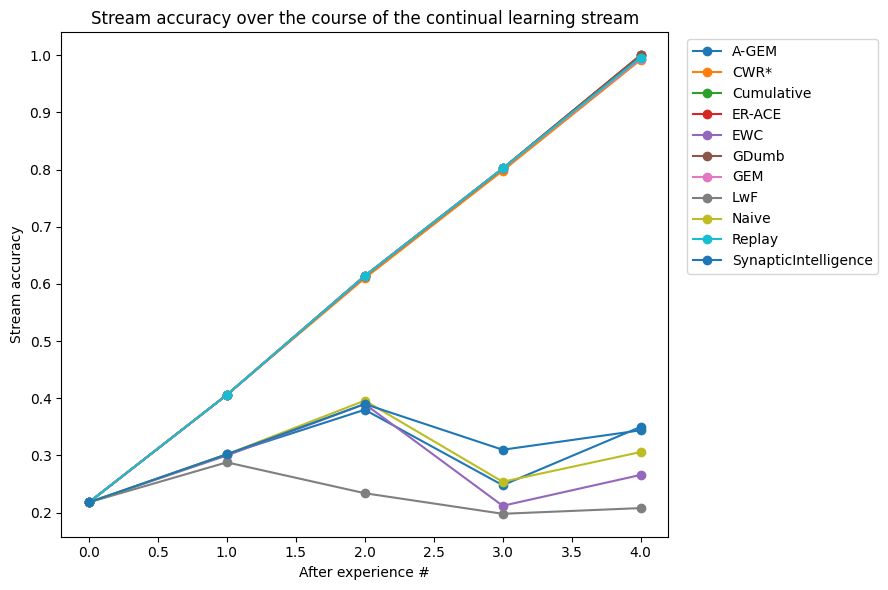

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
for strategy_name, group in all_results.groupby("strategy"):
    group = group.sort_values("after_experience")
    if group["after_experience"].nunique() < 2:
        continue  # skip single-point entries (e.g. JointTraining, SkillMemory summary row)
    ax.plot(group["after_experience"], group["stream_acc"], marker="o", label=strategy_name)

ax.set_xlabel("After experience #")
ax.set_ylabel("Stream accuracy")
ax.set_title("Stream accuracy over the course of the continual learning stream")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/comparison_over_time.png", dpi=120)
plt.show()


## Summary table (for a README / write-up)

In [5]:
summary = final_per_strategy.copy()
summary["stream_acc"] = (summary["stream_acc"] * 100).round(1).astype(str) + "%"
summary["stream_forgetting"] = (summary["stream_forgetting"] * 100).round(1).astype(str) + "%"
summary.to_csv("../results/summary_table.csv", index=False)
print(summary.to_markdown(index=False))


| strategy             | category            | stream_acc   | stream_forgetting   |
|:---------------------|:--------------------|:-------------|:--------------------|
| Cumulative           | baseline            | 100.0%       | 0.0%                |
| ER-ACE               | replay              | 100.0%       | 0.0%                |
| SkillMemory          | skill-memory (demo) | 100.0%       | 0.0%                |
| JointTraining        | baseline            | 100.0%       | 0.0%                |
| GDumb                | replay              | 100.0%       | 0.0%                |
| Replay               | replay              | 99.6%        | 0.5%                |
| GEM                  | replay              | 99.4%        | 0.7%                |
| CWR*                 | architectural       | 99.2%        | 0.0%                |
| A-GEM                | replay              | 35.0%        | 79.8%               |
| SynapticIntelligence | regularization      | 34.4%        | 80.6%         

## Reading these numbers

- **Naive** should show the highest forgetting (no CL mechanism at all) --
  it's the sanity check that the benchmark is actually hard enough to
  produce forgetting.
- **Cumulative** / **JointTraining** should show near-zero forgetting since
  they either retrain on everything or train on everything jointly.
- **SkillMemory**'s forgetting is 0.0 *by construction* (stored skills are
  provably immutable), but note its comparison here uses an
  oracle-style class-to-skill routing table at eval time (see notebook
  05's closing notes) rather than Avalanche's standard `eval()` call --
  so treat the accuracy number as indicative, not perfectly apples-to-apples,
  until a proper inference-time routing policy is implemented.
- Absolute numbers depend heavily on `class_sep` / `noise` in
  `BENCHMARK_CONFIG` (notebook 00) -- an easy benchmark compresses every
  strategy's differences.
